PROGETTO FINALE: RICONOSCIMENTO GESTI DELLA MANO

Titolo: Sviluppo di una CNN con Data Augmentation per Sasso, Carta, Forbice

1. Obiettivo del Progetto 

L'obiettivo è sviluppare il "cervello" visivo per un videogioco interattivo. Dovrai progettare e addestrare un'Intelligenza Artificiale basata su una Rete Neurale Convoluzionale (CNN) capace di classificare istantaneamente le immagini catturate dalla webcam in tre categorie: Sasso, Carta o Forbice

2. Risorse: Il Dataset

Per questo progetto utilizzeremo il dataset Rock-Paper-Scissors (CGI), composto da oltre 2.500 immagini sintetiche di mani in varie pose su sfondo bianco. 
    ● Training Set: Scarica rps.zip 
    ● Test Set: Scarica rps-test-set.zip 
    
    Nota: Le immagini sono organizzate in sottocartelle corrispondenti alle classi (/rock, /paper, /scissors). 
    Il caricamento deve rispettare questa struttura gerarchica. 

3. Roadmap di Sviluppo 

Fase A: Data Pipeline e Augmentation 
    Utilizza la classe ImageDataGenerator di Keras per gestire il flusso di dati. 
    È richiesto di implementare la Data Augmentation per rendere il modello robusto alle variazioni di posizione e orientamento. 
        ● Normalizzazione: Imposta rescale=1./255. 
        ● Trasformazioni obbligatorie: 
            ○ rotation_range=40 
            ○ width_shift_range=0.2 
            ○ shear_range=0.2 
            ○ horizontal_flip=True ○ fill_mode='nearest'

Fase B: Architettura della Rete (CNN) 
    Progetta una rete neurale sequenziale con i seguenti requisiti tecnici:     
        1. Input Layer: Immagini con dimensione 150x150 pixel a 3 canali (RGB). 
        2. Blocchi Convoluzionali: Almeno 3 o 4 livelli Conv2D alternati a livelli MaxPooling2D. 
        Aumenta progressivamente il numero di filtri (es. 32 -> 64 -> 128). 
        3. Livelli Dens: Un livello Flatten seguito da un livello Dense con almeno 512 neuroni e attivazione relu. 
        4. Output Layer: Un livello Dense con 3 neuroni e attivazione Softmax. 

Fase C: Compilazione e Training 
    Configura il processo di addestramento con i seguenti parametri: 
        ● Optimizer: Adam o RMSprop. 
        ● Loss Function: categorical_crossentropy. 
        ● Metriche: accuracy. 
        ● Epoche: Esegui il training per 15-20 epoche. 
        ● Callback: Implementa una EarlyStopping o una callback personalizzata per interrompere l'addestramento se l'accuratezza supera il 98%. 
        
Fase D: Test e Validazione "Wild" 
    Dopo il training, verifica l'efficacia del modello: 
        1. Validazione: Valuta le performance sul dataset di test fornito. 
        2. Test Reale: Utilizza lo snippet di codice per la webcam (se in ambiente Colab) per scattare una foto della tua mano. 
        3. Analisi del Domain Gap: Confronta i risultati ottenuti sulle immagini CGI rispetto alle foto reali della tua mano su sfondo neutro. 
        
4. Linee Guida e Best Practices 

    ● Gestione della Memoria: Assicurati di usare il caricamento a batch per non saturare la RAM. 
    ● Sfondo: Ricorda che il modello è addestrato su sfondi bianchi puliti. Per i test reali, usa una parete chiara o uno sfondo uniforme per minimizzare il rumore visivo. 
    ● Pre-processing: Verifica che le immagini di test subiscano lo stesso processo di ridimensionamento (150x150) e normalizzazione (1/255) applicato al training set.


In [1]:
import os

# 1. SETUP DEL BACKEND (Best Practice 2026)
# Keras 3 permette di scrivere codice una volta ed eseguirlo ovunque. 
# Forziamo PyTorch come motore matematico per sfruttare i suoi kernel ottimizzati.
os.environ["KERAS_BACKEND"] = "torch"

from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Parametri del progetto
IMAGE_HEIGHT = 150
IMAGE_WIDTH = 150
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

BATCH_SIZE = 32
NUM_CLASSES = 3
EPOCHS = 20


print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU disponibili:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
Keras: 3.15.1
GPU disponibili: []


In [2]:
# 1. IL PILASTRO DELLA RIPRODUCIBILITÀ (SEEDING)
def init_reproducibility(seed=42):
    """
    Imposta il seme aleatorio su tutti i livelli del software stack.
    Teoria: L'inizializzazione dei pesi (es. Glorot) usa distribuzioni 
    probabilistiche. Fissando il seed, la 'casuallità' diventa deterministica.
    """
    # Seme per le operazioni native di Python (es. shuffle di liste)
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    
    # Seme per Numpy (gestione dei vettori e preprocessing)
    np.random.seed(seed)
    
    # Seme globale di TensorFlow (inizializzazione pesi e dropout)
    # Nel 2026, questa funzione sincronizza anche i seed dei generatori interni
    tf.keras.utils.set_random_seed(seed)
    
    # Forza TensorFlow a usare operazioni deterministiche su GPU (se disponibili)
    # Nota: Questo può rallentare leggermente il training ma garantisce l'identità dei bit
    tf.config.experimental.enable_op_determinism()
    print(f"[*] Ambiente impostato con Seed: {seed}")

# 2. GESTIONE MEMORIA E COSTI (MIXED PRECISION)
def setup_optimization():
    """
    Abilita la Mixed Precision per dimezzare l'uso della VRAM.
    Teoria: Usa float16 per i calcoli e float32 per le variabili critiche.
    Riduce i costi cloud accelerando il training sulle GPU moderne.
    """
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print(f"[*] Ottimizzazione VRAM: {policy.compute_dtype} abilitata")

# --- ESECUZIONE PIPELINE ---
init_reproducibility(42)
setup_optimization()


[*] Ambiente impostato con Seed: 42
[*] Ottimizzazione VRAM: float16 abilitata


In [3]:
# definizione cartelle di lavoro

from pathlib import Path


PROJECT_DIR = Path(r"C:\EPICODE\Epicode_Python_AI_MachineLearning")
#cartella salvataggio immagini
DATA_DIR = PROJECT_DIR / "data"
TRAIN_DIR = DATA_DIR / "rps"
TEST_DIR = DATA_DIR / "rps-test-set"
#cartella file zip
TRAIN_ZIP = PROJECT_DIR / "rps.zip"
TEST_ZIP = PROJECT_DIR / "rps-test-set.zip"
#cartella e file modello
MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "rps_best_model.keras"
# cartella 
WILD_TEST_DIR = PROJECT_DIR / "wild_test"

print("Cartella progetto:", PROJECT_DIR)
print("Training ZIP:", TRAIN_ZIP)
print("Training ZIP trovato:", TRAIN_ZIP.exists())
print("Test ZIP:", TEST_ZIP)
print("Test ZIP trovato:", TEST_ZIP.exists())

Cartella progetto: C:\EPICODE\Epicode_Python_AI_MachineLearning
Training ZIP: C:\EPICODE\Epicode_Python_AI_MachineLearning\rps.zip
Training ZIP trovato: True
Test ZIP: C:\EPICODE\Epicode_Python_AI_MachineLearning\rps-test-set.zip
Test ZIP trovato: True


2. Risorse: Il Dataset

Per questo progetto utilizzeremo il dataset Rock-Paper-Scissors (CGI), composto da oltre 2.500 immagini sintetiche di mani in varie pose su sfondo bianco. 
    ● Training Set: Scarica rps.zip 
    ● Test Set: Scarica rps-test-set.zip 
    
    Nota: Le immagini sono organizzate in sottocartelle corrispondenti alle classi (/rock, /paper, /scissors). 
    Il caricamento deve rispettare questa struttura gerarchica. 

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile


# URL ufficiali del dataset
TRAIN_URL = ("https://storage.googleapis.com/download.tensorflow.org/data/rps.zip")
TEST_URL = ("https://storage.googleapis.com/download.tensorflow.org/data/rps-test-set.zip")

def download_file_if_needed(url: str,destination: Path,) -> None:
    """
    Scarica il file solo se non è già presente.
    """

    if destination.exists():
        print(f"[OK] File già presente: {destination}")
        return

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(f"[INFO] Download di {destination.name}...")

    try:
        urlretrieve(url,destination,)
    except Exception as error:
        # Elimina l'eventuale file incompleto.
        if destination.exists():
            destination.unlink()

        raise RuntimeError(f"Download fallito: {url}") from error

    print(f"[OK] Download completato: {destination}")


def extract_zip_if_needed(zip_path: Path,expected_directory: Path,destination: Path,) -> None:
    """
    Estrae lo ZIP solo se la cartella attesa
    non è già presente.
    """

    if expected_directory.exists():
        print(f"[OK] Cartella già presente: {expected_directory}")
        return

    if not zip_path.exists():
        raise FileNotFoundError(f"File ZIP non trovato: {zip_path}")

    destination.mkdir(parents=True,exist_ok=True,)

    print(f"[INFO] Estrazione di {zip_path.name}...")

    with ZipFile(zip_path, "r") as archive:
        archive.extractall(destination)

    if not expected_directory.exists():
        raise RuntimeError("Estrazione completata, ma la cartella attesa non è stata trovata: {expected_directory}")

    print(f"[OK] Estrazione completata: {expected_directory}")


#Download
download_file_if_needed(TRAIN_URL,TRAIN_ZIP,)
download_file_if_needed(TEST_URL,TEST_ZIP,)

#Estrazione
extract_zip_if_needed(TRAIN_ZIP,TRAIN_DIR,DATA_DIR,)
extract_zip_if_needed(TEST_ZIP,TEST_DIR,DATA_DIR,)


[OK] File già presente: C:\EPICODE\Epicode_Python_AI_MachineLearning\rps.zip
[OK] File già presente: C:\EPICODE\Epicode_Python_AI_MachineLearning\rps-test-set.zip
[OK] Cartella già presente: C:\EPICODE\Epicode_Python_AI_MachineLearning\data\rps
[OK] Cartella già presente: C:\EPICODE\Epicode_Python_AI_MachineLearning\data\rps-test-set


In [ ]:
#CONTROLLO DEL DATASET e suddivisione in cartelle specifiche

CLASSI = {"paper","rock","scissors",}
ESTENSIONI = {".png",".jpg",".jpeg",".bmp",".webp",}

def validate_dataset_directory(directory: Path,)-> dict[str, int]:

    if not directory.exists():
        raise FileNotFoundError(f"Cartella non trovata: {directory}\nControllare i percorsi o estrarre correttamente gli ZIP.")

    # Recupera i nomi delle sottocartelle in un set (set = dati univoci).
    # Devono essere paper, rock e scissors.
    classi_trovate = {path.name for path in directory.iterdir() if path.is_dir()}

    if classi_trovate != CLASSI:
        raise ValueError(
            f"Classi attese: {sorted(CLASSI)}\n"
            f"Classi trovate: {sorted(classi_trovate)}\n"
            f"Cartella: {directory}"
        )

    counts = {}

    print(f"\nDataset: {directory}")

    # Scorre le tre classi.
    for classe in sorted(CLASSI):
        classe_directory = directory / classe
        #Lista di immagini della classe (solo con estensioni previste)
        immagini = [path for path in classe_directory.rglob("*") if path.is_file() and path.suffix.lower() in ESTENSIONI]
        counts[classe] = len(immagini)
        print(f"{classe}: {len(immagini)} immagini")
        if not immagini:
            raise ValueError(f"La classe '{classe}' non contiene immagini.")

    print(f"Totale: {sum(counts.values())} immagini")

    return counts


train_counts = validate_dataset_directory(TRAIN_DIR)
test_counts = validate_dataset_directory(TEST_DIR)


Dataset: C:\EPICODE\Epicode_Python_AI_MachineLearning\data\rps
paper: 840 immagini
rock: 840 immagini
scissors: 840 immagini
Totale: 2520 immagini

Dataset: C:\EPICODE\Epicode_Python_AI_MachineLearning\data\rps-test-set
paper: 124 immagini
rock: 124 immagini
scissors: 124 immagini
Totale:  372 immagini


3. Roadmap di Sviluppo 

Fase A: Data Pipeline e Augmentation 
    Utilizza la classe ImageDataGenerator di Keras per gestire il flusso di dati. 
    È richiesto di implementare la Data Augmentation per rendere il modello robusto alle variazioni di posizione e orientamento. 
        ● Normalizzazione: Imposta rescale=1./255. 
        ● Trasformazioni obbligatorie: 
            ○ rotation_range=40 
            ○ width_shift_range=0.2 
            ○ shear_range=0.2 
            ○ horizontal_flip=True ○ fill_mode='nearest'

- Training: normalizzazione più augmentation.
- Validation: sola normalizzazione.
- Test: sola normalizzazione.

In [9]:

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0, #normalizzazione
    rotation_range=40, #rotazione immmagini fino a 40 gradi
    width_shift_range=0.2, #spostamento orizzontale
    shear_range=0.2, #deformazione inclinata
    horizontal_flip=True, #immagine speculare
    fill_mode="nearest",
    validation_split=0.20, #20% per traing
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.20,
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    directory=str(TRAIN_DIR), #recupera la classe dal nome della cartella
    target_size=IMAGE_SIZE, #ridimensiona immagine (150x150)
    color_mode="rgb", #3 canali di coloro
    class_mode="categorical", #le etichette delle classi vengono trasformate con codifica one-hot
    batch_size=BATCH_SIZE, #dimensione del batch (quante immagini sono passate al modello contemporaneamente)
    subset="training", #solo per il training non per il validation (20%)
    shuffle=True, #mescola l'ordine delle immagini
)

validation_generator = validation_datagen.flow_from_directory(
    directory=str(TRAIN_DIR),
    target_size=IMAGE_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    subset="validation",
    shuffle=False, #non mescolo per il validation
)

test_generator = test_datagen.flow_from_directory(
    directory=str(TEST_DIR),
    target_size=IMAGE_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False, #non mescolo
)

Found 2016 images belonging to 3 classes.
Found 504 images belonging to 3 classes.
Found 372 images belonging to 3 classes.


In [ ]:
print("Classi training:", train_generator.class_indices)
print("Classi validation:", validation_generator.class_indices)
print("Classi test:", test_generator.class_indices)

if not (train_generator.class_indices == validation_generator.class_indices == test_generator.class_indices):
    raise ValueError("La codifica delle classi non coincide tra i dataset.")

index_to_class = {
    index: class_name
    for class_name, index in train_generator.class_indices.items()
}

print("Mappatura indice -> classe:", index_to_class)
print("Training set:", train_generator.samples)
print("Validation set:", validation_generator.samples)
print("Test set:", test_generator.samples)

Classi training: {'paper': 0, 'rock': 1, 'scissors': 2}
Classi validation: {'paper': 0, 'rock': 1, 'scissors': 2}
Classi test: {'paper': 0, 'rock': 1, 'scissors': 2}
Mappatura indice -> classe: {0: 'paper', 1: 'rock', 2: 'scissors'}
Training set: 2016
Validation set: 504
Test set: 372


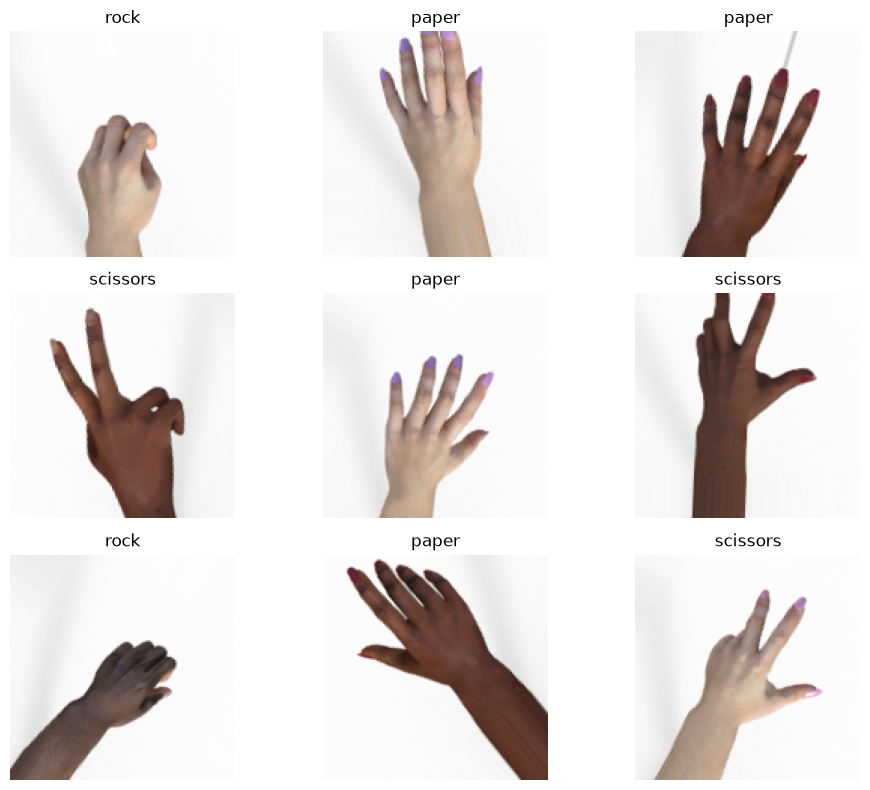

In [12]:
# CONTROLLO VISIVO DELL'AUTMENTATION

images, labels = next(train_generator)

plt.figure(figsize=(10, 8))

for index in range(min(9, len(images))):
    plt.subplot(3, 3, index + 1)
    plt.imshow(images[index])
    label_index = int(np.argmax(labels[index]))
    plt.title(index_to_class[label_index])
    plt.axis("off")

plt.tight_layout()
plt.show()
train_generator.reset()


Fase B: Architettura della Rete (CNN) 
    Progetta una rete neurale sequenziale con i seguenti requisiti tecnici:     
        1. Input Layer: Immagini con dimensione 150x150 pixel a 3 canali (RGB). 
        2. Blocchi Convoluzionali: Almeno 3 o 4 livelli Conv2D alternati a livelli MaxPooling2D. 
        Aumenta progressivamente il numero di filtri (es. 32 -> 64 -> 128). 
        3. Livelli Dens: Un livello Flatten seguito da un livello Dense con almeno 512 neuroni e attivazione relu. 
        4. Output Layer: Un livello Dense con 3 neuroni e attivazione Softmax. 

In [13]:
def build_model() -> keras.Model:
    return keras.Sequential(
        [
            #Input layer
            keras.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), name="input_image"),
            #1.blocco convoluzionale (Conv2d trova le caratteristiche, MaxPooling2D riduce le dimensioni
            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D((2, 2)),
            #2.blocco convoluzionale aumento filtri a 64
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D((2, 2)),
            #3.blocco convoluzionale aumento filtri a 128
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D((2, 2)),
            #4.blocco convoluzionale
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D((2, 2)),
            #layer flatten trasforma le feature map tridimensionali in un vettore monodimensionale
            #necessario per il layer Dense
            layers.Flatten(),
            # Dense layer completamente connesso, attiva i neuroni in base alla caratteristiche apprese nei layer precedenti
            #relu trasfora i negativi in 0
            layers.Dense(512, activation="relu"),
            layers.Dropout(0.5),
            #softmax converte in probabilità
            layers.Dense(NUM_CLASSES, activation="softmax", name="class_probabilities"),
        ],
        name="rps_cnn",
    )

model = build_model()
model.summary()

Model: "rps_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     5,308,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,551,299 (21.18 MB)

 Trainable params: 5,551,299 (21.18 MB)

 Non-trainable params: 0 (0.00 B)

Fase C: Compilazione e Training 
    Configura il processo di addestramento con i seguenti parametri: 
        ● Optimizer: Adam o RMSprop. 
        ● Loss Function: categorical_crossentropy. 
        ● Metriche: accuracy. 
        ● Epoche: Esegui il training per 15-20 epoche. 
        ● Callback: Implementa una EarlyStopping o una callback personalizzata per interrompere l'addestramento se l'accuratezza supera il 98%

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3), #ottimizzatore che aggiorna i pesi
    loss=keras.losses.CategoricalCrossentropy(), #funzione di perdita
    metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")],
)

#callback personalizzata
#interrompo automaticamente il training quando val_accuracy raggiunge 98%
#personalmente non metterei questo limite, ma l'esercizio lo chiede
class StopAtValidationAccuracy(keras.callbacks.Callback):
    def __init__(self, threshold: float = 0.98):
        super().__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        validation_accuracy = logs.get("val_accuracy")

        if validation_accuracy is not None and validation_accuracy >= self.threshold:
            print(f"\n[STOP] Val_accuracy raggiunta: {validation_accuracy:.2%}")
            self.model.stop_training = True

#callback standard
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=4,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    StopAtValidationAccuracy(threshold=0.98),
    keras.callbacks.TerminateOnNaN(),
]


In [15]:
#training
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.4826 - loss: 0.9855
Epoch 1: val_loss improved from None to 0.68873, saving model to C:\EPICODE\Epicode_Python_AI_MachineLearning\models\rps_best_model.keras

Epoch 1: finished saving model to C:\EPICODE\Epicode_Python_AI_MachineLearning\models\rps_best_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 431ms/step - accuracy: 0.4826 - loss: 0.9855 - val_accuracy: 0.5198 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.8879 - loss: 0.3311
Epoch 2: val_loss improved from 0.68873 to 0.11365, saving model to C:\EPICODE\Epicode_Python_AI_MachineLearning\models\rps_best_model.keras

Epoch 2: finished saving model to C:\EPICODE\Epicode_Python_AI_MachineLearning\models\rps_best_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 391ms/step - accuracy: 0.8879 - loss: 0.3311 - val_accuracy: 0.9782 - val_loss: 0.1136 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/st

Il modello converge alla 6 epoca con questi dati avendo raggiunto il 98% nella val_accuracy (come da callbacks impostata):
Val_accuracy=98.02% ; val_loss=0.0708
accuracy=98.96%; loss=0.0323

Il training è andato complessivamente bene, con una convergenza rapida. Il modello ha raggiunto il 98% di accuratezza di validazione in 6 epoche, senza completare tutte le 20 epoche

Nella prima epoca, il modello essendo nella fase iniziale, non ha imparato caratteristiche sufficientemente efficace
Già dalla epoca 2 ho un netto miglioramento
All'epoca 4 ho un peggioramento
Durante l'addestramento è entrato il funzione la callbacks ReduceLROnPlateau portando il lr a 0.0005 e poi a 0.0010, consentendo al modello di effettuare aggiornamenti a piccoli passi precisi. 
Con la riduzione del lr all'epoca 4 ho un effetto positivo sulla val_loss, questo recupero mostra che il peggioramento dell'epoca 4 non era overfitting


Fase D: Test e Validazione "Wild" 
    Dopo il training, verifica l'efficacia del modello: 
        1. Validazione: Valuta le performance sul dataset di test fornito. 
        2. Test Reale: Utilizza lo snippet di codice per la webcam (se in ambiente Colab) per scattare una foto della tua mano. 
        3. Analisi del Domain Gap: Confronta i risultati ottenuti sulle immagini CGI rispetto alle foto reali della tua mano su sfondo neutro. 

* Curve di training

- Training e validation migliorano insieme: situazione sana.
- Training migliora e validation peggiora: overfitting.
- Entrambe restano basse: underfitting o pipeline errata.

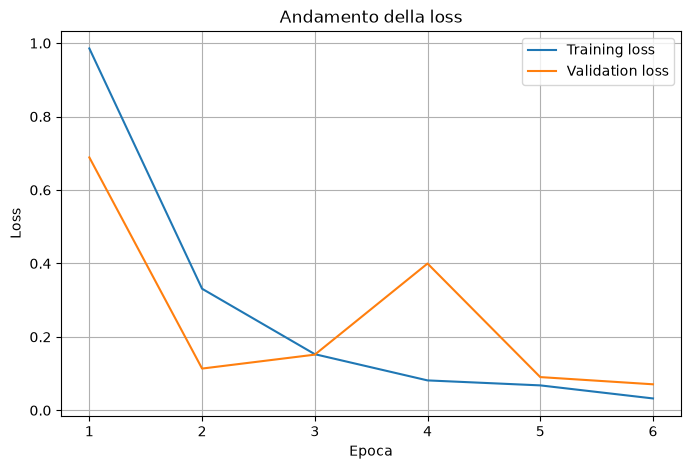

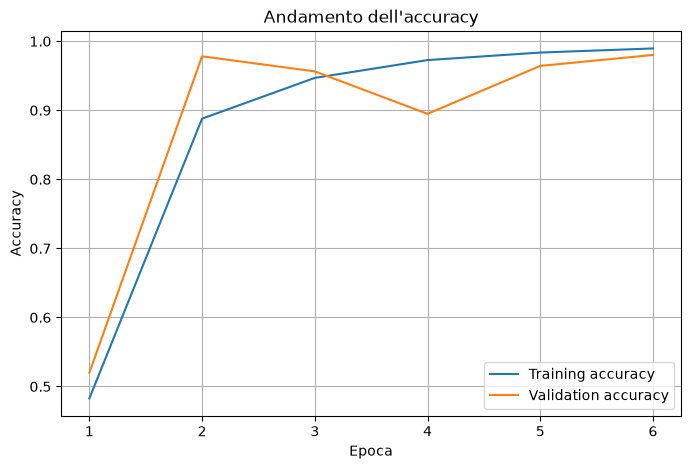

In [16]:
def plot_training_history(history: keras.callbacks.History) -> None:
    epochs_range = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history.history["loss"], label="Training loss")
    plt.plot(epochs_range, history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoca")
    plt.ylabel("Loss")
    plt.title("Andamento della loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history.history["accuracy"], label="Training accuracy")
    plt.plot(epochs_range, history.history["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoca")
    plt.ylabel("Accuracy")
    plt.title("Andamento dell'accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_history(history)


In [17]:
#Valutazione sul test set
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Modello non trovato: {MODEL_PATH}")

best_model = keras.models.load_model(MODEL_PATH)
test_generator.reset()

test_results = best_model.evaluate(
    test_generator,
    return_dict=True,
    verbose=1,
)

print("\nRisultati sul test set")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name:15s}: {metric_value:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.9866 - loss: 0.0365

Risultati sul test set
accuracy       : 0.9866
loss           : 0.0365


La CNN riesce ad apprendre efficacemente le caratteristiche che distinguono le 3 classi: sasso, carta, forbice.
L'addestramento mostra una convergenza rapida. La training  loss diminuisce la maggior parte nella prima epoca, mentre la accuracy arriva quasi al 99%
Anche per la validation ho buoni risultatil La accuracy raggiunge circa il 98% la loss si mantiene bassa per arrivare a 0.06.
La vicinandza tra le curve di training e di validatio suggerisce non sia presente un overfitting 
All'epoca 4 si osserva un peggioramento temporaneo della validation loss accompagnato, nello stesso periodo, da una riduzione della validation accuracy. Il comportamento non continua nelle epoche successive, non facendo pensare ad un overfitting.

Nel complesso il modello raggiunge ottime prestazioni sul dataset appartenente allo stesso dominio delle immagini di addestramento. Questo non dimostra che il modello sia altrettanto 'bravo' su immagini acquisita tramite foto del cellulare o altri dispositivi.

11 Classification report e matrice di confusione
(per vedere quali gesti sono confusi)

In [18]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

ANALISI DELLA IMMAGINI CLASSIFICATE 'BENE'

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
              precision    recall  f1-score   support

       paper     1.0000    0.9597    0.9794       124
        rock     1.0000    1.0000    1.0000       124
    scissors     0.9612    1.0000    0.9802       124

    accuracy                         0.9866       372
   macro avg     0.9871    0.9866    0.9866       372
weighted avg     0.9871    0.9866    0.9866       372



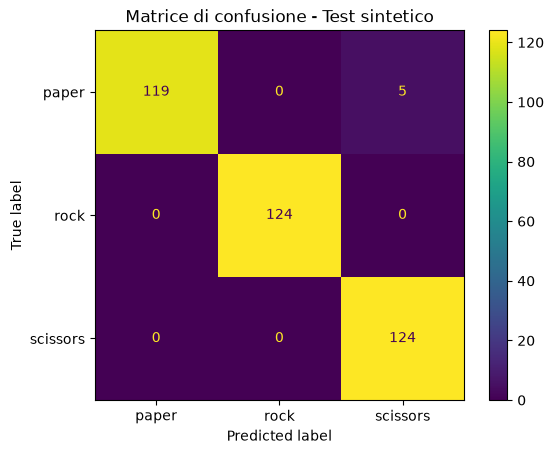

In [19]:
test_generator.reset()
probabilities = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(probabilities, axis=1)
true_classes = test_generator.classes
class_names = [index_to_class[index] for index in range(len(index_to_class))]

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(true_classes, predicted_classes)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(values_format="d")
plt.title("Matrice di confusione - Test sintetico")
plt.show()


La matrice evidenzia prestazioni elevate sul test set, ha classificato correttamente 367 immagini su 372.
La classe 'rock' è stata predetta correttamente in tutti i casi
Anche la classe 'scissors' non mostra errori
La classe 'paper' dove 5 sono state classificate come scissors, presentando una limitato sovrapposizione tra paper e scissors.

ANALISI DELLE IMMAGINI CLASSIFICATE 'MALE'

Errori totali: 5


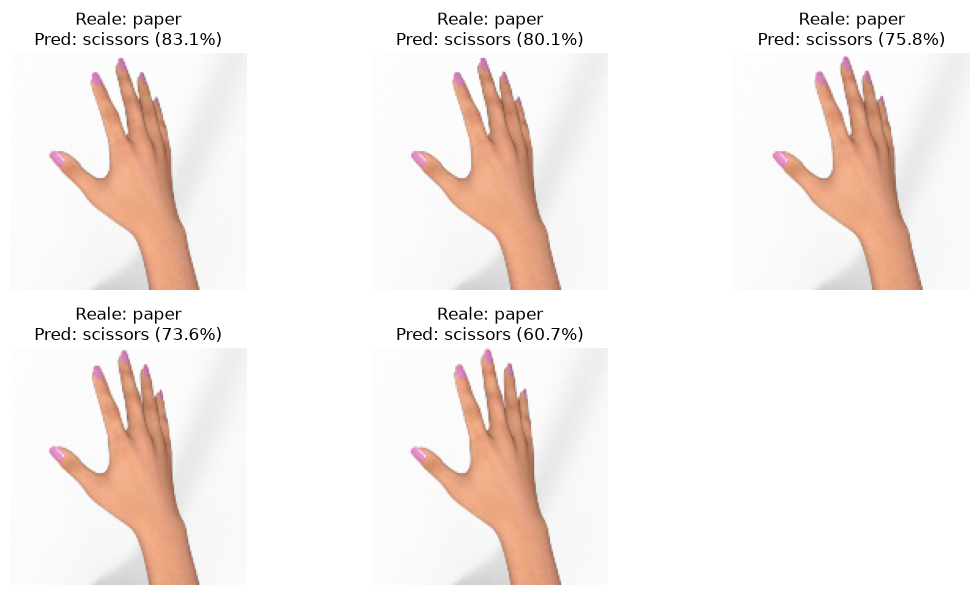

In [20]:
file_paths = np.array(test_generator.filepaths)
wrong_indices = np.where(predicted_classes != true_classes)[0]
print("Errori totali:", len(wrong_indices))

if len(wrong_indices) == 0:
    print("Nessun errore nel test set.")
else:
    number_to_show = min(9, len(wrong_indices))
    plt.figure(figsize=(11, 9))

    for plot_index, sample_index in enumerate(wrong_indices[:number_to_show]):
        image = keras.utils.load_img(file_paths[sample_index], target_size=IMAGE_SIZE)
        true_name = index_to_class[int(true_classes[sample_index])]
        predicted_name = index_to_class[int(predicted_classes[sample_index])]
        confidence = probabilities[sample_index, predicted_classes[sample_index]]

        plt.subplot(3, 3, plot_index + 1)
        plt.imshow(image)
        plt.title(f"Reale: {true_name}\nPred: {predicted_name} ({confidence:.1%})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


le 5 immagini classificate male presentano tutte le stesse caratteristiche: la stessa mano con orientamento diagonale. Le immagini sembrano quasi duplicati o variazioni minime dello stesso campione. Potrebbe essere utile aggiungere più immagini di 'paper' con mani inclinate.

Previsione di una singola immagine

In [21]:
def predict_image(model: keras.Model,image_path: str | Path,index_to_class: dict[int, str],) -> dict:
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Immagine non trovata: {image_path}")

    image = keras.utils.load_img(image_path,target_size=IMAGE_SIZE,color_mode="rgb",)
    image_array = keras.utils.img_to_array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    probabilities = model.predict(image_array, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))

    return {
        "classe": index_to_class[predicted_index],
        "confidenza": float(probabilities[predicted_index]),
        "probabilita": {
            index_to_class[index]: float(probability)
            for index, probability in enumerate(probabilities)
        },
    }


#Esempio con immagine di mano effettiva
IMMAGINE_EFFETTIVA = PROJECT_DIR / "mia_mano.jpg"
result = predict_image(best_model, IMMAGINE_EFFETTIVA, index_to_class)
print(result)


{'classe': 'rock', 'confidenza': 1.0, 'probabilita': {'paper': 5.960464477539062e-07, 'rock': 1.0, 'scissors': 0.00022017955780029297}}


Classificazione corretta 'rock'

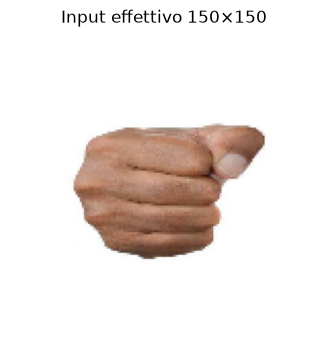

Shape: (150, 150, 3)
Min: 0.019607844
Max: 1.0


In [22]:
#immagine vista dalla rete (quella predetta male)
IMMAGINE_EFFETTIVA = PROJECT_DIR / "mia_mano.jpg"
image = keras.utils.load_img(
    IMMAGINE_EFFETTIVA,
    target_size=IMAGE_SIZE,
    color_mode="rgb",
)

image_array = keras.utils.img_to_array(image)
image_array = image_array.astype("float32") / 255.0

plt.figure(figsize=(4, 4))
plt.imshow(image_array)
plt.title("Input effettivo 150×150")
plt.axis("off")
plt.show()

print("Shape:", image_array.shape)
print("Min:", image_array.min())
print("Max:", image_array.max())

GIOCO

In [27]:
# OpenCV gestisce la webcam e la finestra del gioco.
# Nel terminale di VS Code, se non è installato:
# python -m pip install opencv-python

try:
    import cv2
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "OpenCV non è installato. Nel terminale eseguire: "
        "python -m pip install opencv-python"
    ) from error

import time

# Se il notebook viene riaperto senza rieseguire il test precedente,
# carica automaticamente il modello migliore salvato su disco.
if "best_model" not in globals():
    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f"Modello non trovato: {MODEL_PATH}\n"
            "Eseguire prima il training oppure controllare MODEL_PATH."
        )

    best_model = keras.models.load_model(MODEL_PATH)

print("Modello pronto per il gioco:", MODEL_PATH)
print("Classi disponibili:", index_to_class)

ModuleNotFoundError: OpenCV non è installato. Nel terminale eseguire: python -m pip install opencv-python

In [26]:
def avvia_gioco_webcam(
    model: keras.Model = best_model,
    camera_index: int = 0,
    confidence_threshold: float = 0.70,
) -> None:
    """
    Avvia il gioco interattivo Sasso, Carta, Forbici con la webcam.

    Comandi:
    - SPAZIO: nuovo round;
    - R: azzera il punteggio;
    - Q: chiude la finestra.
    """

    if not 0.0 <= confidence_threshold <= 1.0:
        raise ValueError("confidence_threshold deve essere compresa tra 0 e 1.")

    # Su Windows DirectShow riduce spesso il tempo di apertura della webcam.
    if os.name == "nt":
        camera = cv2.VideoCapture(camera_index, cv2.CAP_DSHOW)

        # Alcune webcam non supportano DirectShow: in tal caso usa il backend standard.
        if not camera.isOpened():
            camera.release()
            camera = cv2.VideoCapture(camera_index)
    else:
        camera = cv2.VideoCapture(camera_index)

    if not camera.isOpened():
        raise RuntimeError(
            "Impossibile aprire la webcam. Provare camera_index=1 oppure "
            "controllare le autorizzazioni di Windows."
        )

    # Risoluzione richiesta alla webcam. Il dispositivo può scegliere
    # automaticamente una risoluzione differente se non la supporta.
    camera.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    camera.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

    punteggio = {
        "giocatore": 0,
        "computer": 0,
        "pareggi": 0,
    }

    conto_alla_rovescia_inizio = None
    messaggio_round = "Posiziona la mano nel riquadro"
    dettaglio_round = "Premi SPAZIO per giocare"
    mostra_risultato_fino_a = 0.0

    nome_finestra = "Sasso, Carta, Forbici - Q per uscire"

    try:
        while True:
            frame_letto, frame = camera.read()

            if not frame_letto or frame is None:
                raise RuntimeError("La webcam non ha restituito un frame valido.")

            # Effetto specchio, più naturale per chi guarda la webcam.
            frame = cv2.flip(frame, 1)
            altezza, larghezza = frame.shape[:2]

            # Riquadro quadrato adattato automaticamente alla risoluzione disponibile.
            lato = int(min(altezza * 0.68, larghezza * 0.42))
            x1 = larghezza - lato - 30
            y1 = max(80, (altezza - lato) // 2)
            x2 = x1 + lato
            y2 = y1 + lato

            # Il ritaglio quadrato riduce la deformazione prima del resize 150x150.
            regione_mano_bgr = frame[y1:y2, x1:x2]

            adesso = time.time()

            # Gestione non bloccante del conto alla rovescia.
            if conto_alla_rovescia_inizio is not None:
                tempo_trascorso = adesso - conto_alla_rovescia_inizio
                secondi_rimanenti = 3 - int(tempo_trascorso)

                if tempo_trascorso < 3:
                    messaggio_round = f"Mostra la mossa: {secondi_rimanenti}"
                    dettaglio_round = "Mantieni la mano nel riquadro"
                else:
                    # OpenCV acquisisce in BGR, mentre il modello è stato
                    # addestrato con immagini RGB.
                    regione_mano_rgb = cv2.cvtColor(
                        regione_mano_bgr,
                        cv2.COLOR_BGR2RGB,
                    )

                    previsione = classifica_frame_rgb(
                        model,
                        regione_mano_rgb,
                        index_to_class,
                    )

                    confidenza = previsione["confidenza"]

                    if confidenza < confidence_threshold:
                        messaggio_round = "Mossa non riconosciuta"
                        dettaglio_round = (
                            f"Confidenza {confidenza:.1%}: riprova"
                        )
                    else:
                        mossa_giocatore = previsione["classe"]
                        mossa_computer = scegli_mossa_computer()
                        esito = determina_esito(
                            mossa_giocatore,
                            mossa_computer,
                        )

                        if esito == "pareggio":
                            punteggio["pareggi"] += 1
                            testo_esito = "PAREGGIO"
                        elif esito == "giocatore":
                            punteggio["giocatore"] += 1
                            testo_esito = "HAI VINTO!"
                        else:
                            punteggio["computer"] += 1
                            testo_esito = "VINCE IL COMPUTER"

                        messaggio_round = testo_esito
                        dettaglio_round = (
                            f"Tu: {ETICHETTE_ITALIANE[mossa_giocatore]}  |  "
                            f"PC: {ETICHETTE_ITALIANE[mossa_computer]}  |  "
                            f"CNN: {confidenza:.1%}"
                        )

                    conto_alla_rovescia_inizio = None
                    mostra_risultato_fino_a = adesso + 3.0

            elif adesso > mostra_risultato_fino_a:
                messaggio_round = "Posiziona la mano nel riquadro"
                dettaglio_round = "Premi SPAZIO per giocare"

            # Riquadro della zona analizzata dal modello.
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                3,
            )

            # Pannello scuro superiore per rendere leggibile il testo.
            cv2.rectangle(
                frame,
                (0, 0),
                (larghezza, 78),
                (25, 25, 25),
                thickness=-1,
            )

            cv2.putText(
                frame,
                messaggio_round,
                (20, 32),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.85,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )

            cv2.putText(
                frame,
                dettaglio_round,
                (20, 64),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.58,
                (220, 220, 220),
                1,
                cv2.LINE_AA,
            )

            testo_punteggio = (
                f"Tu {punteggio['giocatore']}  -  "
                f"Computer {punteggio['computer']}  -  "
                f"Pareggi {punteggio['pareggi']}"
            )

            cv2.putText(
                frame,
                testo_punteggio,
                (20, altezza - 48),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.72,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )

            cv2.putText(
                frame,
                "SPAZIO: gioca   R: reset   Q: esci",
                (20, altezza - 18),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (220, 220, 220),
                1,
                cv2.LINE_AA,
            )

            cv2.imshow(nome_finestra, frame)

            tasto = cv2.waitKey(1) & 0xFF

            if tasto == ord("q"):
                break

            if tasto == ord("r"):
                punteggio = {
                    "giocatore": 0,
                    "computer": 0,
                    "pareggi": 0,
                }
                conto_alla_rovescia_inizio = None
                mostra_risultato_fino_a = 0.0
                messaggio_round = "Punteggio azzerato"
                dettaglio_round = "Premi SPAZIO per giocare"

            # 32 è il codice del tasto SPAZIO.
            if tasto == 32 and conto_alla_rovescia_inizio is None:
                conto_alla_rovescia_inizio = time.time()
                messaggio_round = "Mostra la mossa: 3"
                dettaglio_round = "Mantieni la mano nel riquadro"

    finally:
        camera.release()
        cv2.destroyAllWindows()

    print("Gioco terminato.")
    print("Punteggio finale:", punteggio)

In [25]:
# Eseguire questa cella quando si è pronti ad aprire la webcam.
# Durante il gioco la finestra OpenCV deve essere selezionata
# affinché i tasti SPAZIO, R e Q vengano letti correttamente.

avvia_gioco_webcam(
    model=best_model,
    camera_index=0,
    confidence_threshold=0.70,
)

NameError: name 'cv2' is not defined